Advanced EDA Lab - 5/29/2026 - johpro1668

In [1]:
# Import necessary libraries
import pandas as pd
from datetime import datetime
from IPython.display import display, Markdown
todays_date = datetime.now().strftime("%Y-%m-%d")
student_id = "johpro1668"

# Load the Titanic dataset
data = pd.read_csv('C:/Users/ecpi/Downloads/Credit_card_data.csv')

# Display the first few rows to understand what the data looks like
display(Markdown("### Step 1: Load the Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
display(data.head())

### Step 1: Load the Dataset

Date: 2026-05-29

Student ID: johpro1668

,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
0,yes,0.0,37.66667,4.5200,0.033270,124.983300,yes,no,3.0,54,1,12.0
1,yes,0.0,33.25000,2.4200,0.005217,9.854167,no,no,3.0,34,1,13.0
2,yes,0.0,33.66667,4.5000,0.004156,15.000000,yes,no,4.0,58,1,5.0
3,yes,0.0,30.50000,2.5400,0.065214,137.869200,no,no,0.0,25,1,7.0
4,yes,0.0,32.16667,9.7867,0.067051,546.503300,yes,no,2.0,64,1,5.0


In [2]:
display(Markdown("### Step 2: Initial Exploration of the Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Get a concise summary of the DataFrame
print(data.info())

# Get descriptive statistics that summarize the central tendency, dispersion, and shape of the dataset's numerical features
display(data.describe())

### Step 2: Initial Exploration of the Dataset

Date: 2026-05-29

Student ID: johpro1668

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   card         1319 non-null   object 
 1   reports      1311 non-null   float64
 2   age          1319 non-null   float64
 3   income       1319 non-null   float64
 4   share        1319 non-null   float64
 5   expenditure  1319 non-null   float64
 6   owner        1319 non-null   object 
 7   selfemp      1312 non-null   object 
 8   dependents   1318 non-null   float64
 9   months       1319 non-null   int64  
 10  majorcards   1319 non-null   int64  
 11  active       1311 non-null   float64
dtypes: float64(7), int64(2), object(3)
memory usage: 123.8+ KB
None


,reports,age,income,share,expenditure,dependents,months,majorcards,active
count,1311.000000,1319.000000,1319.000000,1319.000000,1319.000000,1318.000000,1319.000000,1319.000000,1311.000000
mean,0.457666,33.213103,3.365376,0.068732,185.057071,0.994689,55.267627,0.817286,7.017544
std,1.348848,10.142783,1.693902,0.094656,272.218917,1.247918,66.271746,0.386579,6.319158
min,0.000000,0.166667,0.210000,0.000109,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,25.416670,2.243750,0.002316,4.583333,0.000000,12.000000,1.000000,2.000000
50%,0.000000,31.250000,2.900000,0.038827,101.298300,1.000000,30.000000,1.000000,6.000000
75%,0.000000,39.416670,4.000000,0.093617,249.035800,2.000000,72.000000,1.000000,11.000000
max,14.000000,83.500000,13.500000,0.906320,3099.505000,6.000000,540.000000,1.000000,46.000000


In [3]:
from sklearn.preprocessing import StandardScaler

display(Markdown("### Step 3: Data Preprocessing"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Check for missing values in the dataset
missing_values = data.isnull().sum()
print(f"Missing values in each column:\n{missing_values}")

# Fill missing values for numerical columns with the median
numeric_features = [
    'reports', 'age', 'income', 'share', 'expenditure', 'dependents', 'months', 'majorcards', 'active'
]
for col in numeric_features:
    data[col].fillna(data[col].median(), inplace=True)

# Fill missing boolean values with mode
bool_features = ['card', 'owner', 'selfemp']
for col in bool_features:
    data[col].fillna(data[col].mode()[0], inplace=True)

# Verify that there are no remaining missing values
missing_values_after = data.isnull().sum()
print(f"Missing values after cleaning:\n{missing_values_after}")

scaler = StandardScaler()
data[numeric_features] = scaler.fit_transform(data[numeric_features])
display(data.head())

# Change yes/no columns to binary values
string_cols  = ['card', 'owner', 'selfemp']

for col in string_cols:
    if col in data.columns:
        data[col] = data[col].map({'yes': 1, 'no': 0})

### Step 3: Data Preprocessing

Date: 2026-05-29

Student ID: johpro1668

Missing values in each column:
card           0
reports        8
age            0
income         0
share          0
expenditure    0
owner          0
selfemp        7
dependents     1
months         0
majorcards     0
active         8
dtype: int64
Missing values after cleaning:
card           0
reports        0
age            0
income         0
share          0
expenditure    0
owner          0
selfemp        0
dependents     0
months         0
majorcards     0
active         0
dtype: int64


C:\Users\ecpi\AppData\Local\Temp\ipykernel_7604\3135901659.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].median(), inplace=True)
C:\Users\ecpi\AppData\Local\Temp\ipykernel_7604\3135901659.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
0,yes,-0.338282,0.439254,0.681894,-0.374787,-0.220766,yes,no,1.608142,-0.019135,0.472824,0.792090
1,yes,-0.338282,0.003639,-0.558317,-0.671269,-0.643854,no,no,1.608142,-0.321037,0.472824,0.950869
2,yes,-0.338282,0.044735,0.670083,-0.682486,-0.624944,yes,no,2.410085,0.041245,0.472824,-0.319364
3,yes,-0.338282,-0.267592,-0.487448,-0.037185,-0.173411,no,no,-0.797687,-0.456893,0.472824,-0.001806
4,yes,-0.338282,-0.103209,3.792286,-0.017772,1.328281,yes,no,0.806199,0.131816,0.472824,-0.319364


### Step 4: Univariate Analysis

Date: 2026-05-29

Student ID: johpro1668

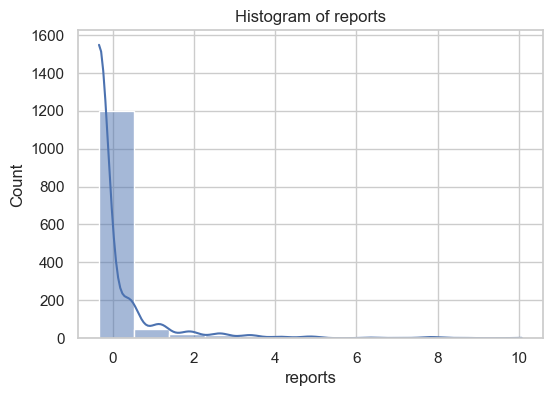

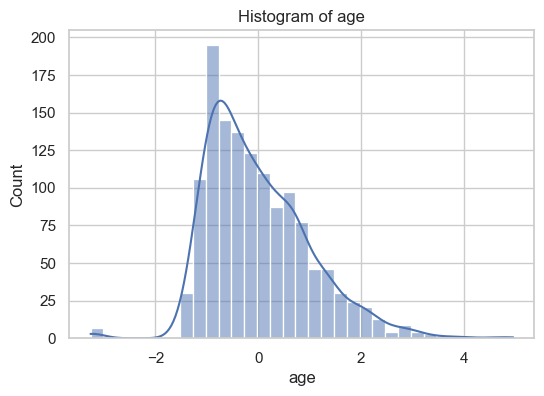

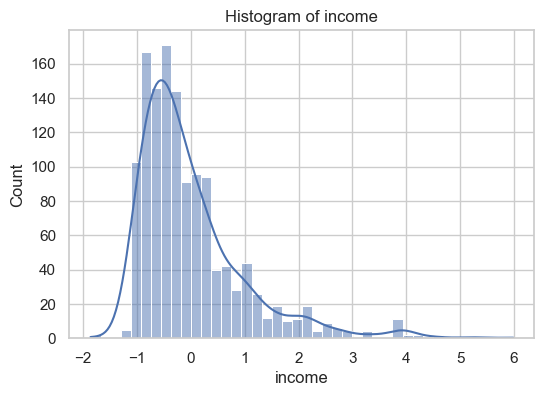

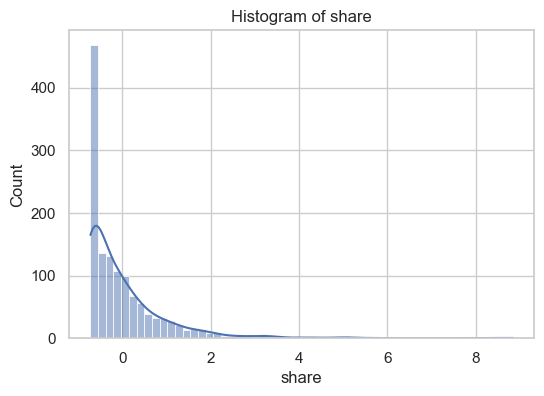

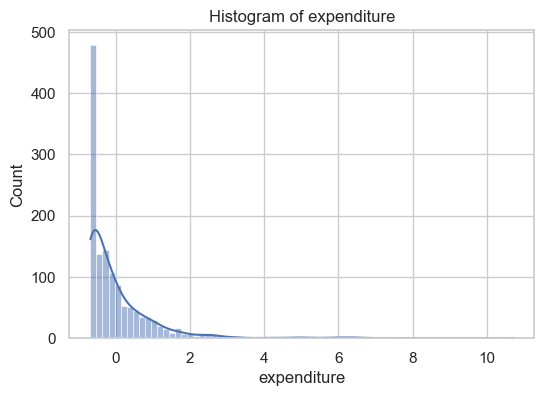

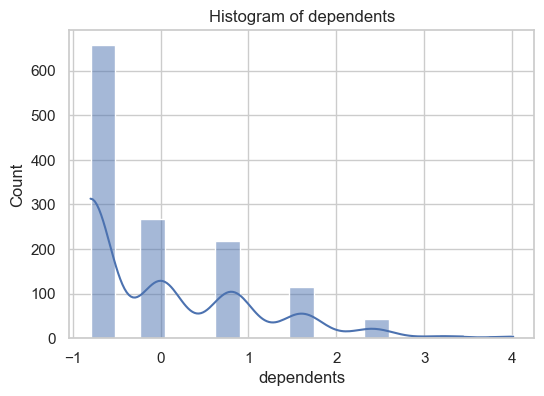

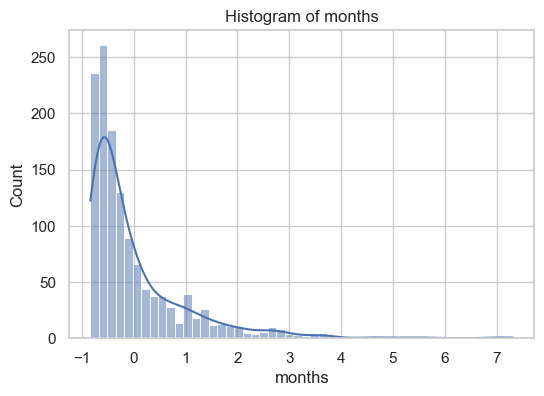

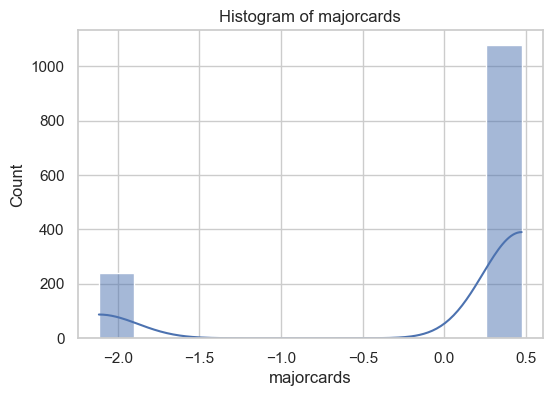

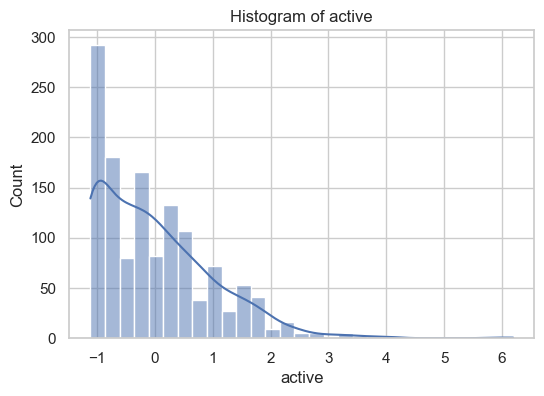

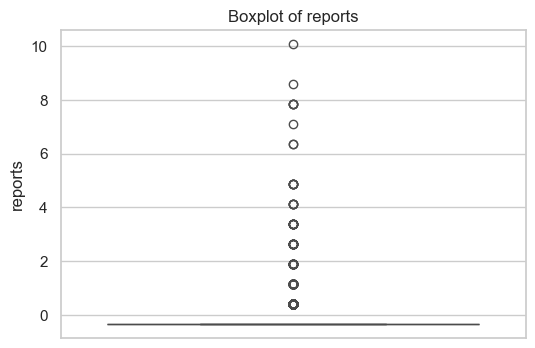

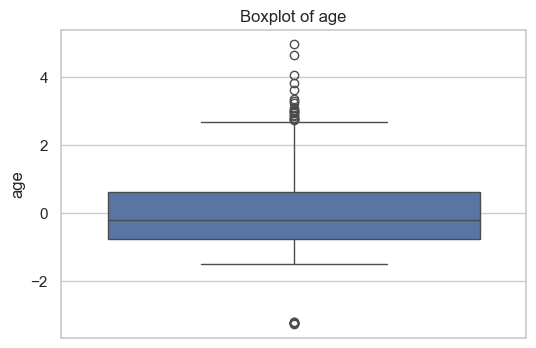

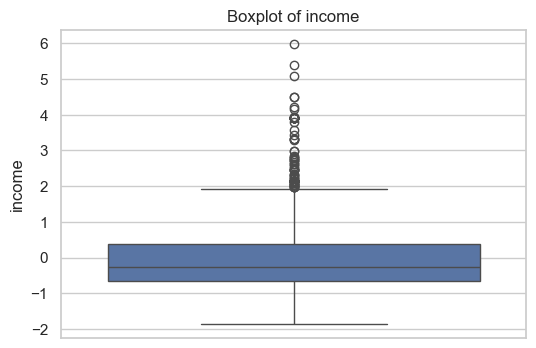

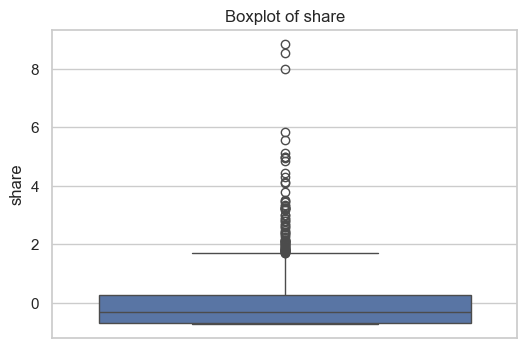

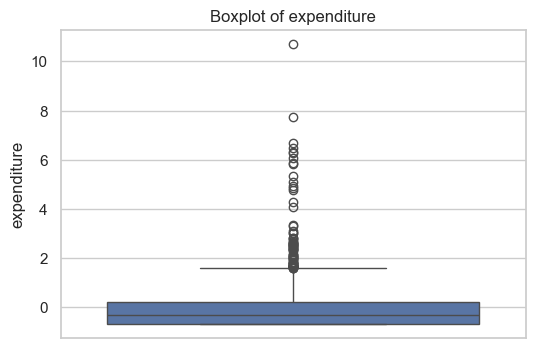

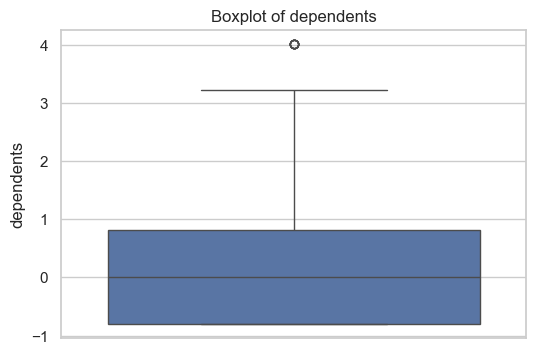

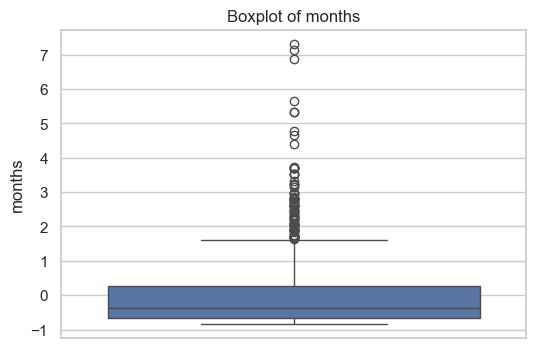

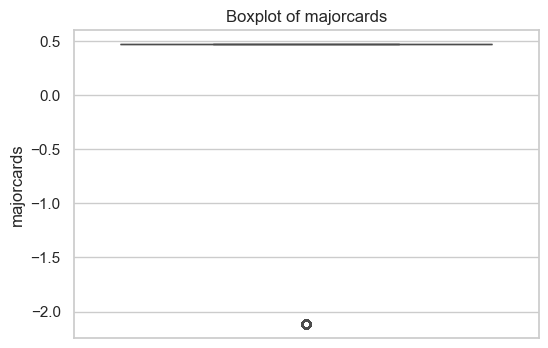

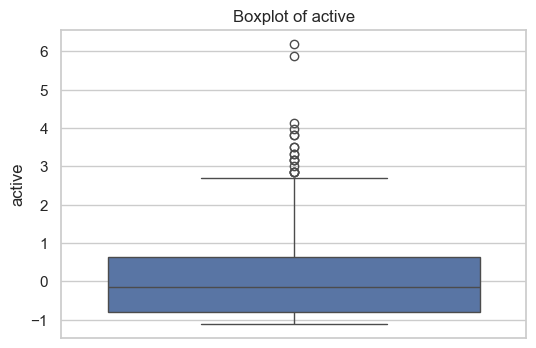

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

display(Markdown("### Step 4: Univariate Analysis"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Set the aesthetic style of the plots
sns.set(style="whitegrid")

# Plot histograms for numerical features
for feature in numeric_features:
    plt.figure(figsize=(6, 4))
    sns.histplot(data[feature], kde=True)
    plt.title(f'Histogram of {feature}')
    plt.show()

# Plot boxplots for numerical features
for feature in numeric_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=data[feature])
    plt.title(f'Boxplot of {feature}')
    plt.show()

### Step 5: Bivariate Analysis

Date: 2026-05-29

Student ID: johpro1668

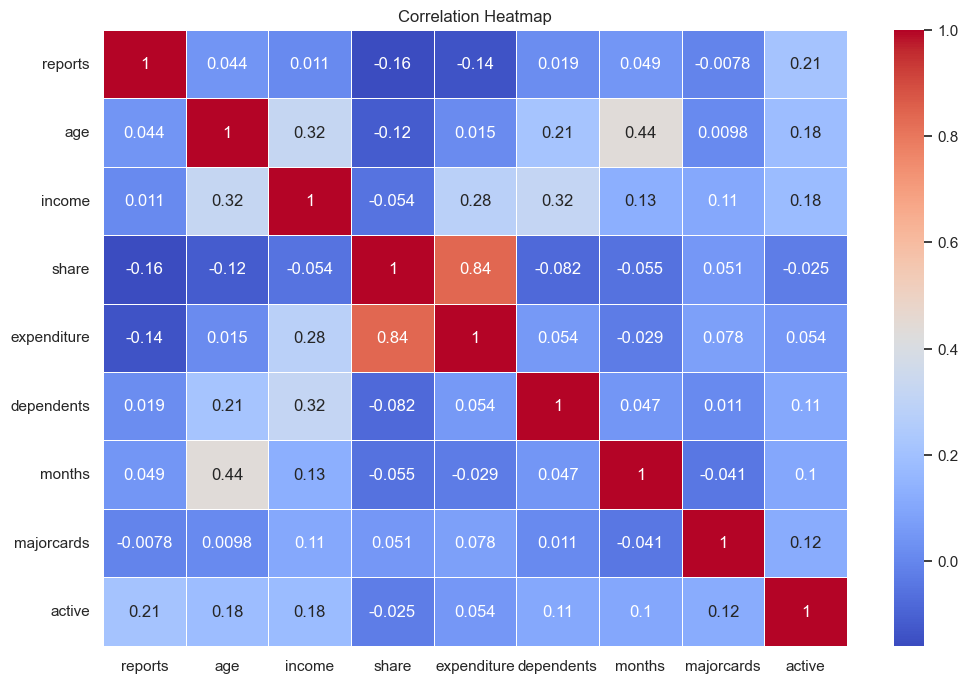

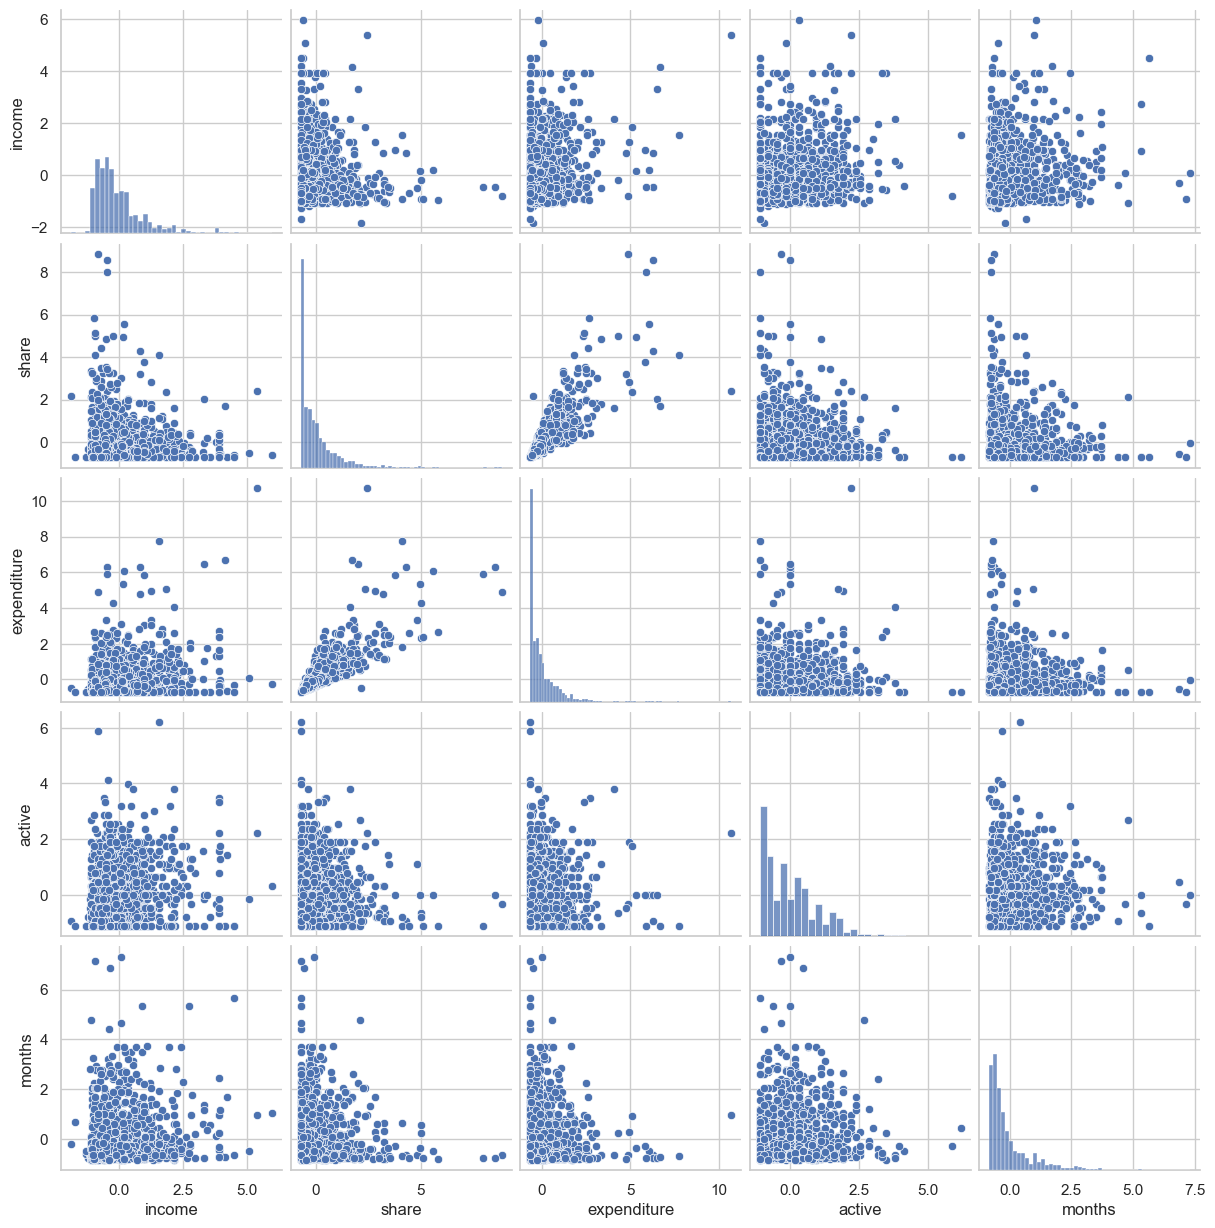

In [5]:
display(Markdown("### Step 5: Bivariate Analysis"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Correlation Matrix
cm = data[numeric_features].corr()

plt.figure(figsize=(12,8))
sns.heatmap(cm, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# Pair Plots for clustering features
cluster_features = ['income', 'share', 'expenditure', 'active', 'months']
sns.pairplot(data[cluster_features])
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

display(Markdown("### Step 6: Model Design"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

data['NegativeReport'] = (data['reports'] > 0).astype(int)
X = data.drop(columns=['reports', 'NegativeReport'])
y = data['NegativeReport']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])


print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

### Step 6: Model Design

Date: 2026-05-29

Student ID: johpro1668

X_train shape: (1055, 11)
X_test shape: (264, 11)
y_train shape: (1055,)
y_test shape: (264,)


C:\Users\ecpi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Step 7: Model Training

Date: 2026-05-29

Student ID: johpro1668

Epoch 1/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.2543 - loss: 0.7739 - val_accuracy: 0.6730 - val_loss: 0.6582
Epoch 2/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7281 - loss: 0.6255 - val_accuracy: 0.8104 - val_loss: 0.5279
Epoch 3/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7929 - loss: 0.5137 - val_accuracy: 0.8152 - val_loss: 0.4488
Epoch 4/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8135 - loss: 0.4378 - val_accuracy: 0.8152 - val_loss: 0.4312
Epoch 5/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7834 - loss: 0.4752 - val_accuracy: 0.8152 - val_loss: 0.4264
Epoch 6/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8076 - loss: 0.4208 - val_accuracy: 0.8152 - val_loss: 0.4254
Epoch 7/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8084 - loss: 0.4002 - val_accuracy: 0.8152 - val_loss: 0.4230
Epoch 8/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7849 - loss: 0.4289 - val_accuracy: 0.8104 - val_loss

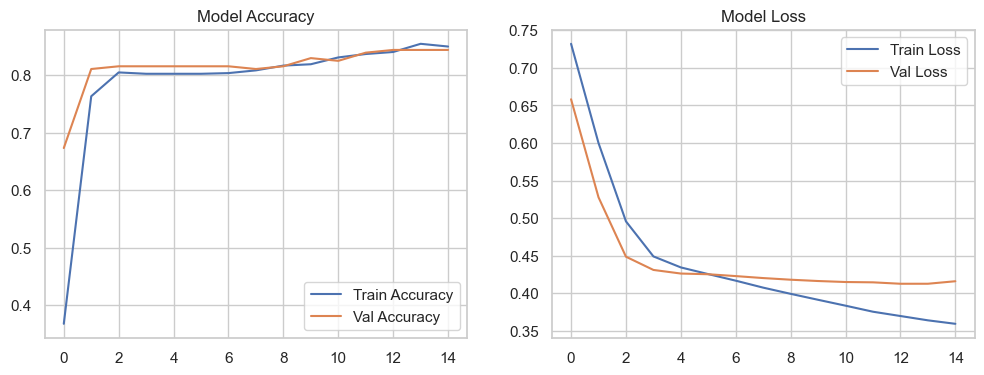

In [7]:
import matplotlib.pyplot as plt


display(Markdown("### Step 7: Model Training"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    verbose=1
)

plt.figure(figsize=(12, 4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Model Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Model Loss')
plt.show()


In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

display(Markdown("### Step 7.2: Regression Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

X_reg = data.drop(columns=['expenditure', 'NegativeReport'])
y_reg = data['expenditure']

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

reg_model = LinearRegression()
reg_model.fit(X_reg_train, y_reg_train)

y_reg_pred = reg_model.predict(X_reg_test)

mae = mean_absolute_error(y_reg_test, y_reg_pred)
mse = mean_squared_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_reg_test, y_reg_pred)



### Step 7.2: Regression Model

Date: 2026-05-29

Student ID: johpro1668

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

display(Markdown("### Step 7.3: Clustering Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

cluster_features = ['income', 'expenditure', 'share', 'active', 'months']
X_cluster = data[cluster_features]

cluster_model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

data['Cluster'] = cluster_model.fit_predict(X_cluster)
silhouette = silhouette_score(X_cluster, data['Cluster'])
cluster_summary = data.groupby('Cluster')[cluster_features].mean()


### Step 7.3: Clustering Model

Date: 2026-05-29

Student ID: johpro1668

In [10]:
from sklearn.metrics import classification_report

display(Markdown("### Step 8: Model Evaluation"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

display(Markdown(f"Classification Model"))
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

y_pred = (model.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred))

display(Markdown(f"Regression Model"))
print(f"Regression MAE: {mae:.4f}")
print(f"Regression RMSE: {rmse:.4f}")
print(f"Regression R² Score: {r2:.4f}")

display(Markdown(f"Clustering Model"))
print(f"Clustering Silhouette Score: {silhouette:.4f}")
display(cluster_summary)

### Step 8: Model Evaluation

Date: 2026-05-29

Student ID: johpro1668

Classification Model

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step - accuracy: 0.8907 - loss: 0.3107  
Test Accuracy: 0.8712
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
              precision    recall  f1-score   support

           0       0.87      0.99      0.93       213
           1       0.87      0.39      0.54        51

    accuracy                           0.87       264
   macro avg       0.87      0.69      0.73       264
weighted avg       0.87      0.87      0.85       264



Regression Model

Regression MAE: 0.2521
Regression RMSE: 0.5284
Regression R² Score: 0.7702


Clustering Model

Clustering Silhouette Score: 0.3002


,income,expenditure,share,active,months
Cluster,,,,,
0,0.713765,-0.114332,-0.281830,0.879230,0.732912
1,-0.352869,-0.317553,-0.262256,-0.416284,-0.330156
2,0.049629,1.931340,2.062310,-0.034188,-0.115863


In [11]:
from sklearn.model_selection import RandomizedSearchCV
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

display(Markdown("### Step 9: Hyperparameter Tuning and Early Stopping"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

def build_model(learning_rate=0.001, n1=32, n2=16):
    m = Sequential([
        Dense(n1, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(n2, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    m.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return m

early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

clf = KerasClassifier(
    model=build_model,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

param_dist = {
    "model__learning_rate": [1e-4, 3e-4, 1e-3, 3e-3],
    "model__n1": [16, 32, 64],
    "model__n2": [8, 16, 32],
    "batch_size": [16, 32, 64],
}

search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_params = search.best_params_
best_cv_acc = search.best_score_

print("Best params:", best_params)
print("Best CV accuracy:", best_cv_acc)


### Step 9: Hyperparameter Tuning and Early Stopping

Date: 2026-05-29

Student ID: johpro1668

C:\Users\ecpi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Best params: {'model__n2': 8, 'model__n1': 32, 'model__learning_rate': 0.003, 'batch_size': 16}
Best CV accuracy: 0.8445458862125529


In [12]:

display(Markdown("### Step 10: Retrain Tuned Model and Evaluate"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

best_lr = best_params["model__learning_rate"]
best_n1 = best_params["model__n1"]
best_n2 = best_params["model__n2"]
best_bs = best_params["batch_size"]

model_tuned = build_model(learning_rate=best_lr, n1=best_n1, n2=best_n2)

history_tuned = model_tuned.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=best_bs,
    callbacks=[early_stop],
    verbose=1
)

tuned_loss, tuned_acc = model_tuned.evaluate(X_test, y_test, verbose=0)
print(f"Tuned Test Accuracy: {tuned_acc:.4f}")
print(f"Tuned Test Loss: {tuned_loss:.4f}")


### Step 10: Retrain Tuned Model and Evaluate

Date: 2026-05-29

Student ID: johpro1668

Epoch 1/30


C:\Users\ecpi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5549 - loss: 0.6750 - val_accuracy: 0.8152 - val_loss: 0.4643
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8179 - loss: 0.4227 - val_accuracy: 0.8294 - val_loss: 0.4139
Epoch 3/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8524 - loss: 0.3672 - val_accuracy: 0.8578 - val_loss: 0.3962
Epoch 4/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8481 - loss: 0.3679 - val_accuracy: 0.8626 - val_loss: 0.3905
Epoch 5/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8748 - loss: 0.3558 - val_accuracy: 0.8531 - val_loss: 0.3846
Epoch 6/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8354 - loss: 0.3801 - val_accuracy: 0.8578 - val_loss: 0.3858
Epoch 7/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8598 - loss: 0.3658 - val_accuracy: 0.8578 - val_loss: 0.3925
Epoch 8/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8797 - loss: 0.3199 - val_accuracy: 0.8578 - val_loss: 0.3917
Tu

In [13]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

display(Markdown("### Step 10.2: Tuning Regression Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

ridge_model = Ridge()

ridge_params = {
    'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
}

ridge_search = GridSearchCV(
    ridge_model,
    ridge_params,
    cv=5,
    scoring='r2'
)

ridge_search.fit(X_reg_train, y_reg_train)

reg_model_tuned = ridge_search.best_estimator_

y_reg_tuned_pred = reg_model_tuned.predict(X_reg_test)

mae_tuned = mean_absolute_error(y_reg_test, y_reg_tuned_pred)
mse_tuned = mean_squared_error(y_reg_test, y_reg_tuned_pred)
rmse_tuned = np.sqrt(mse_tuned)
r2_tuned = r2_score(y_reg_test, y_reg_tuned_pred)

print("Best Alpha:", ridge_search.best_params_['alpha'])
print(f"Tuned MAE: {mae_tuned:.4f}")
print(f"Tuned RMSE: {rmse_tuned:.4f}")
print(f"Tuned R²: {r2_tuned:.4f}")

### Step 10.2: Tuning Regression Model

Date: 2026-05-29

Student ID: johpro1668

Best Alpha: 10.0
Tuned MAE: 0.2509
Tuned RMSE: 0.5304
Tuned R²: 0.7685


In [14]:
display(Markdown("### Step 10.3: Tuning Cluster Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

best_k = 2
best_score = -1

for k in range(2, 7):

    temp_cluster_model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    temp_clusters = temp_cluster_model.fit_predict(X_cluster)

    temp_score = silhouette_score(
        X_cluster,
        temp_clusters
    )

    if temp_score > best_score:
        best_score = temp_score
        best_k = k

cluster_model_tuned = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

data['Cluster_Tuned'] = cluster_model_tuned.fit_predict(X_cluster)

print(f"Best Number of Clusters: {best_k}")
print(f"Tuned Silhouette Score: {best_score:.4f}")

### Step 10.3: Tuning Cluster Model

Date: 2026-05-29

Student ID: johpro1668

Best Number of Clusters: 2
Tuned Silhouette Score: 0.3712


In [18]:

display(Markdown("### Step 11: Untuned vs Tuned Comparison"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

display(Markdown(f"""
## Classification

| Model | Test Accuracy | Test Loss |
|---|---:|---:|
| Original Neural Network | `{test_accuracy:.4f}` | `{test_loss:.4f}` |
| Tuned Neural Network | `{tuned_acc:.4f}` | `{tuned_loss:.4f}` |

## Regression

| Model | MAE | RMSE | R² |
|---|---:|---:|---:|
| Linear Regression | `{mae:.4f}` | `{rmse:.4f}` | `{r2:.4f}` |
| Tuned Regression | `{mae_tuned:.4f}` | `{rmse_tuned:.4f}` | `{r2_tuned:.4f}` |

## Clustering

| Model | Clusters | Silhouette Score |
|---|---:|---:|
| Original K-Means | `3` | `{silhouette:.4f}` |
| Tuned K-Means | `{best_k}` | `{best_score:.4f}` |
"""))


### Step 11: Untuned vs Tuned Comparison

Date: 2026-05-29

Student ID: johpro1668


## Classification

| Model | Test Accuracy | Test Loss |
|---|---:|---:|
| Original Neural Network | `0.8712` | `0.3358` |
| Tuned Neural Network | `0.8939` | `0.3085` |

## Regression

| Model | MAE | RMSE | R² |
|---|---:|---:|---:|
| Linear Regression | `0.2521` | `0.5284` | `0.7702` |
| Tuned Regression | `0.2509` | `0.5304` | `0.7685` |

## Clustering

| Model | Clusters | Silhouette Score |
|---|---:|---:|
| Original K-Means | `3` | `0.3002` |
| Tuned K-Means | `2` | `0.3712` |



1. **Economic Downturn:** Lower customer financial capacity and spending behavior.  
   - Assumption: `income` and `expenditure` decrease, representing reduced earnings and reduced spending.  
   - Why test: Economic stress can change credit behavior and risk patterns.

2. **Economic Growth / Higher Spending:** Stronger finances and increased spending.  
   - Assumption: `income` and `expenditure` increase, representing improved earnings and higher spending activity.  
   - Why test: Growth periods can shift approval/risk profiles and model predictions.

3. **Increased Credit Utilization / Activity Shift:** Changes in utilization-like behavior and account activity.  
   - Assumption: `share` increases (proxy for heavier usage/utilization behavior) and `active` increases.  
   - Why test: Utilization and activity are often strong drivers of credit-related outcomes and may materially impact predicted risk.



In [16]:
import numpy as np

display(Markdown("### Step 13: Scenario Simulation"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Baseline predictions using original X_test (unchanged)
baseline_pred = model_tuned.predict(X_test).reshape(-1)
baseline_prob = float(np.mean(baseline_pred))

# Scenario 1: Economic Downturn (income↓, expenditure↓)
X_downturn = X_test.copy()
if 'income' in X_downturn.columns:
    X_downturn['income'] = X_downturn['income'] - 0.5
if 'expenditure' in X_downturn.columns:
    X_downturn['expenditure'] = X_downturn['expenditure'] - 0.5

# Scenario 2: Economic Growth (income↑, expenditure↑)
X_growth = X_test.copy()
if 'income' in X_growth.columns:
    X_growth['income'] = X_growth['income'] + 0.5
if 'expenditure' in X_growth.columns:
    X_growth['expenditure'] = X_growth['expenditure'] + 0.5

# Scenario 3: Higher Utilization / Activity (share↑, active↑)
X_util = X_test.copy()
if 'share' in X_util.columns:
    X_util['share'] = X_util['share'] + 0.5
if 'active' in X_util.columns:
    X_util['active'] = X_util['active'] + 0.5

# Predict scenario outcomes
downturn_pred = model_tuned.predict(X_downturn).reshape(-1)
growth_pred = model_tuned.predict(X_growth).reshape(-1)
util_pred = model_tuned.predict(X_util).reshape(-1)

downturn_prob = float(np.mean(downturn_pred))
growth_prob = float(np.mean(growth_pred))
util_prob = float(np.mean(util_pred))

display(Markdown(f"**Baseline Avg Predicted Probability (X_test):** `{baseline_prob:.4f}`"))

display(Markdown(f"- **Economic Downturn** Avg Prob: `{downturn_prob:.4f}` | delta: `{downturn_prob - baseline_prob:+.4f}`"))
display(Markdown(f"- **Economic Growth** Avg Prob: `{growth_prob:.4f}` | delta: `{growth_prob - baseline_prob:+.4f}`"))
display(Markdown(f"- **Higher Utilization / Activity** Avg Prob: `{util_prob:.4f}` | delta: `{util_prob - baseline_prob:+.4f}`"))

### Step 13: Scenario Simulation

Date: 2026-05-29

Student ID: johpro1668

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


**Baseline Avg Predicted Probability (X_test):** `0.2028`

- **Economic Downturn** Avg Prob: `0.2169` | delta: `+0.0142`

- **Economic Growth** Avg Prob: `0.1940` | delta: `-0.0088`

- **Higher Utilization / Activity** Avg Prob: `0.2315` | delta: `+0.0287`

### Step 14: Sensitivity Analysis for features 'income' and 'share'

Date: 2026-05-29

Student ID: johpro1668

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


,delta_income,delta_share,avg_pred_prob
0,-1.0,-1.0,0.248144
1,-1.0,-0.5,0.222396
2,-1.0,0.0,0.199883
3,-1.0,0.5,0.180631
4,-1.0,1.0,0.168169


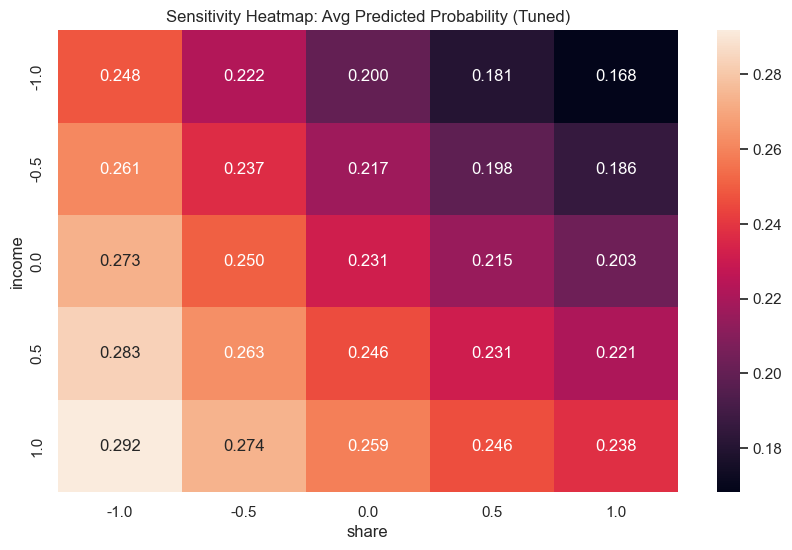

In [17]:
display(Markdown("### Step 14: Sensitivity Analysis for features 'income' and 'share'"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Use Scenario 3 (X_util) as the base for sensitivity analysis
X_sens = X_util.copy()

sens_steps = [-1.0, -0.5, 0.0, 0.5, 1.0]
sens_results = []

if 'income' in X_sens.columns and 'share' in X_sens.columns:
    for di in sens_steps:
        for ds in sens_steps:
            X_tmp = X_sens.copy()
            X_tmp['income'] = X_tmp['income'] + di
            X_tmp['share'] = X_tmp['share'] + ds

            tmp_pred = model_tuned.predict(X_tmp).reshape(-1)
            tmp_prob = float(np.mean(tmp_pred))

            sens_results.append({
                "delta_income": di,
                "delta_share": ds,
                "avg_pred_prob": tmp_prob
            })

    sens_df = pd.DataFrame(sens_results)
    display(sens_df.head())

    pivot_table = sens_df.pivot(index="delta_income", columns="delta_share", values="avg_pred_prob")

    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot_table, annot=True, fmt=".3f")
    plt.title("Sensitivity Heatmap: Avg Predicted Probability (Tuned)")
    plt.xlabel("share")
    plt.ylabel("income")
    plt.show()

